In [ ]:
anno_path = "datasets/ASV2/rec_detailed_description_42k_wo_square_pad.json"

import json

with open(anno_path, 'r') as f:
    anno = json.load(f)

print(len(anno))

42551


In [2]:
print(anno[0].keys())

dict_keys(['id', 'image', 'height', 'width', 'conversations'])


In [ ]:
from collections import defaultdict
import re
from PIL import Image, ImageDraw

BOX_SCALE = 999
REF_START_TAG = '<ref>'
REF_END_TAG = '</ref>'
BOX_START_TAG = '<box>'
BOX_END_TAG = '</box>'
REL_START_TAG = '<pred>'
REL_END_TAG = '</pred>'
SQUARE_PAD = True
DEBUG_MODE = False

def extract_objects(
    grounded_caption: str,
    grounded_pattern: str = r'<.*?>.*?<.*?>',
):
    objects = defaultdict(list)
    relations = defaultdict(list)

    clean_caption = grounded_caption
    clean_caption = clean_caption.replace(REF_START_TAG, '').replace(REF_END_TAG, '')
    clean_caption = clean_caption.replace(REL_START_TAG, '').replace(REL_END_TAG, '')
    res = re.findall(grounded_pattern, grounded_caption)

    last_tag = REF_START_TAG
    last_tag_value = 'Unknown'
    for item in res:
        clean_item = re.sub(r'<.*?>', '', item)

        if item.startswith(BOX_START_TAG):
            clean_caption = clean_caption.replace(item, '')
            try:
                clean_item = json.loads(clean_item)
            except Exception as e:
                # print('Invalid format:', clean_item)
                continue
            if last_tag == REF_START_TAG:
                objects[last_tag_value].extend(clean_item)
            elif last_tag == REL_START_TAG:
                relations[last_tag_value].append(clean_item)
            else:
                raise NotImplementedError(grounded_caption)
        else:
            last_tag = REF_START_TAG if item.startswith(REF_START_TAG) else REL_START_TAG
            last_tag_value = clean_item

    bbox2category = defaultdict(list)
    for k, v in objects.items():
        for bbox in v:
            bbox2category[json.dumps(bbox)].append(k)

    return objects, relations, bbox2category

def parse_caption_and_update_image(image: Image, caption: str):
    image = image.copy()
    image_list = []
    caption_list = []
    # sections = []
    objects, relations, bbox2category = extract_objects(caption.replace('<image>', '').replace('</s>', ''))
    for obj_name, bbox_list in objects.items():
        if len(bbox_list) == 0:
            continue
        for idx, bbox in enumerate(bbox_list):
            try:
                x1, y1, x2, y2 = bbox
            except Exception as e:
                continue
            bbox = (
                int(x1 / BOX_SCALE * image.width),
                int(y1 / BOX_SCALE * image.height),
                int(x2 / BOX_SCALE * image.width),
                int(y2 / BOX_SCALE * image.height),
            )
            # sections.append((bbox, f'{obj_name}-{idx}'))
            image_list.append(image.copy())
            caption_list.append(f'{obj_name}-{idx}')

    scene_graph = []
    for rel_name, bbox_list in relations.items():

        for i in range(0, len(bbox_list), 2):
            if i+1 >= len(bbox_list):
                continue

            subject_bboxes = bbox_list[i]
            object_bboxes = bbox_list[i+1]

            if len(subject_bboxes) == 1:
                subject_bboxes = subject_bboxes * len(object_bboxes)

            if len(object_bboxes) == 1:
                object_bboxes = object_bboxes * len(subject_bboxes)

            if len(subject_bboxes) != len(object_bboxes):
                print(f'#subject_bboxes ({len(subject_bboxes)}) is not equal to #object_bboxes ({len(object_bboxes)})')
                print(f'Current caption: {caption}')
                print()

            for idx, (subj_bbox, obj_bbox) in enumerate(zip(subject_bboxes, object_bboxes)):
                subj = bbox2category[json.dumps(subj_bbox)]
                obj = bbox2category[json.dumps(obj_bbox)]

                try:
                    x1, y1, x2, y2 = subj_bbox
                except Exception as e:
                    continue

                subj_bbox = (
                    int(x1 / BOX_SCALE * image.width),
                    int(y1 / BOX_SCALE * image.height),
                    int(x2 / BOX_SCALE * image.width),
                    int(y2 / BOX_SCALE * image.height),
                )

                try:
                    x1, y1, x2, y2 = obj_bbox
                except Exception as e:
                    continue
                obj_bbox = (
                    int(x1 / BOX_SCALE * image.width),
                    int(y1 / BOX_SCALE * image.height),
                    int(x2 / BOX_SCALE * image.width),
                    int(y2 / BOX_SCALE * image.height),
                )

                image_list.append(image.copy())
                caption_list.append(f'{subj}-{rel_name}-{obj}')
                scene_graph.append((subj, subj_bbox, obj, obj_bbox, rel_name))

    return scene_graph

In [ ]:
coco_path = "datasets/COCO/"
import random
random.shuffle(anno)
img_path = coco_path + anno[0]['image']
# load image
image = Image.open(img_path)
scene_graph = parse_caption_and_update_image(image, anno[0]['conversations'][1]['value'])
print(scene_graph)
print(anno[0])

[(['person'], (142, 34, 268, 153), ['skateboard'], (165, 149, 234, 175), 'playing'), (['person'], (142, 34, 268, 153), ['stairs'], (29, 206, 500, 482), 'jumping from'), (['stairs'], (29, 206, 500, 482), ['floor'], (0, 226, 500, 500), 'attached to'), (['people'], (168, 174, 201, 237), ['fence'], (96, 30, 500, 478), 'leaning on'), (['people'], (216, 174, 261, 238), ['fence'], (96, 30, 500, 478), 'leaning on'), (['person', 'people'], (449, 159, 487, 238), ['people'], (436, 157, 463, 238), 'in front of'), (['sky'], (0, 0, 218, 207), ['tree'], (0, 72, 113, 172), 'over')]
{'id': -1, 'image': 'coco/train2017/000000329258.jpg', 'height': 500, 'width': 500, 'conversations': [{'from': 'human', 'value': '<image>\nProvide a scene graph caption of the given image.'}, {'from': 'gpt', 'value': 'In the image, a <ref>person</ref><box>[[285, 69, 537, 307]]</box> is <pred>playing</pred><box>[[285, 69, 537, 307]]</box><box>[[331, 299, 468, 351]]</box> with a <ref>skateboard</ref><box>[[331, 299, 468, 351]

In [6]:
for idx, img_anno in enumerate(anno):
    img_path = coco_path + anno[0]['image']

[(['person'], (142, 34, 268, 153), ['skateboard'], (165, 149, 234, 175), 'playing'), (['person'], (142, 34, 268, 153), ['stairs'], (29, 206, 500, 482), 'jumping from'), (['stairs'], (29, 206, 500, 482), ['floor'], (0, 226, 500, 500), 'attached to'), (['people'], (168, 174, 201, 237), ['fence'], (96, 30, 500, 478), 'leaning on'), (['people'], (216, 174, 261, 238), ['fence'], (96, 30, 500, 478), 'leaning on'), (['person', 'people'], (449, 159, 487, 238), ['people'], (436, 157, 463, 238), 'in front of'), (['sky'], (0, 0, 218, 207), ['tree'], (0, 72, 113, 172), 'over')]


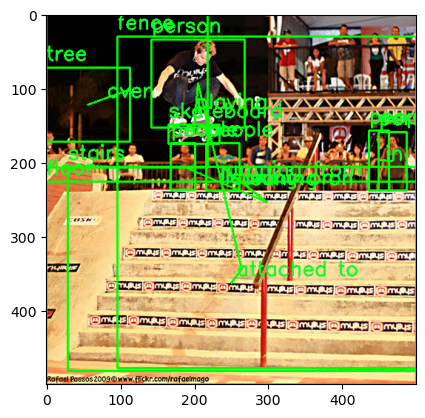

In [7]:
print(scene_graph)
import cv2 
img = cv2.imread(img_path)

for triplet in scene_graph:
    subj, subj_bbox, obj, obj_bbox, rel = triplet

    # draw bounding boxes and labels
    cv2.rectangle(img, (subj_bbox[0], subj_bbox[1]), (subj_bbox[2], subj_bbox[3]), (0, 255, 0), 2)
    cv2.rectangle(img, (obj_bbox[0], obj_bbox[1]), (obj_bbox[2], obj_bbox[3]), (0, 255, 0), 2)
    cv2.putText(img, subj[0], (subj_bbox[0], subj_bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)
    cv2.putText(img, obj[0], (obj_bbox[0], obj_bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)

    # draw line between objects centers
    center_sub = (int((subj_bbox[0] + subj_bbox[2]) / 2), int((subj_bbox[1] + subj_bbox[3]) / 2))
    center_obj = (int((obj_bbox[0] + obj_bbox[2]) / 2), int((obj_bbox[1] + obj_bbox[3]) / 2))

    cv2.line(img, center_sub, center_obj, (0, 255, 0), 2)
    # put text in the middle of the line
    cv2.putText(img, rel, (int((center_sub[0] + center_obj[0]) / 2), int((center_sub[1] + center_obj[1]) / 2)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)

img_cv2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

import matplotlib.pyplot as plt
plt.imshow(img_cv2)

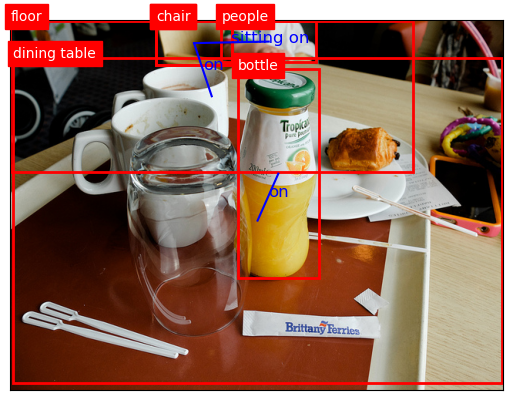

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
coco_path = "datasets/COCO/"
import random
random.shuffle(anno)
img_path = coco_path + anno[0]['image']
# load image
image = Image.open(img_path)
scene_graph = parse_caption_and_update_image(image, anno[0]['conversations'][1]['value'])

fig, ax = plt.subplots()
ax.imshow(image)

for rel in scene_graph:
    subject, subject_bbox, obj, obj_bbox, rel = rel
    subject = subject[0]
    obj = obj[0]

    # draw bbox
    ax.add_patch(patches.Rectangle((subject_bbox[0], subject_bbox[1]), subject_bbox[2]-subject_bbox[0], subject_bbox[3]-subject_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))
    ax.add_patch(patches.Rectangle((obj_bbox[0], obj_bbox[1]), obj_bbox[2]-obj_bbox[0], obj_bbox[3]-obj_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))

    # get center of bbox
    subject_center = ((subject_bbox[0] + subject_bbox[2]) / 2, (subject_bbox[1] + subject_bbox[3]) / 2)
    obj_center = ((obj_bbox[0] + obj_bbox[2]) / 2, (obj_bbox[1] + obj_bbox[3]) / 2)

    # draw line
    ax.plot([subject_center[0], obj_center[0]], [subject_center[1], obj_center[1]], 'blue')

    # draw bboxes labels on top left with background rectangle
    ax.text(subject_bbox[0], subject_bbox[1], subject, fontsize=10, color='white', backgroundcolor='red')
    ax.text(obj_bbox[0], obj_bbox[1], obj, fontsize=10, color='white', backgroundcolor='red')

    # draw relation label on center of line
    ax.text((subject_center[0] + obj_center[0]) / 2, (subject_center[1] + obj_center[1]) / 2, rel, fontsize=12, color='blue')

# remove ticks
ax.set_xticks([])
ax.set_yticks([])
plt.show()

100%|██████████| 42551/42551 [00:06<00:00, 6790.38it/s]


589
295459
6.94364409767103
3.5932880543347983
{'beside': 20154, 'on': 19964, 'over': 16434, 'attached to': 11731, 'standing on': 11253, 'holding': 8439, 'in front of': 7259, 'looking at': 5529, 'sitting on': 5096, 'in': 5020, 'walking on': 4314, 'hanging from': 3256, 'parked on': 3253, 'driving on': 3183, 'wearing': 2930, 'carrying': 2400, 'riding': 1851, 'playing': 1802, 'about to hit': 1331, 'running on': 1306, 'lying on': 1306, 'swinging': 1260, 'touching': 1199, 'eating': 1036, 'talking to': 964, 'leaning on': 932, 'enclosing': 798, 'flying over': 741, 'pulling': 665, 'playing with': 636, 'driving': 615, 'throwing': 457, 'jumping from': 401, 'biting': 376, 'crossing': 333, 'painted on': 305, 'slicing': 293, 'catching': 267, 'going down': 215, 'drinking': 209, 'jumping over': 196, 'kicking': 193, 'enclosed': 193, 'pushing': 172, 'feeding': 142, 'on back of': 136, 'guiding': 127, 'standing beside': 123, 'chasing': 96, 'encloses': 96, 'entering': 92, 'standing in front of': 72, 'sitt

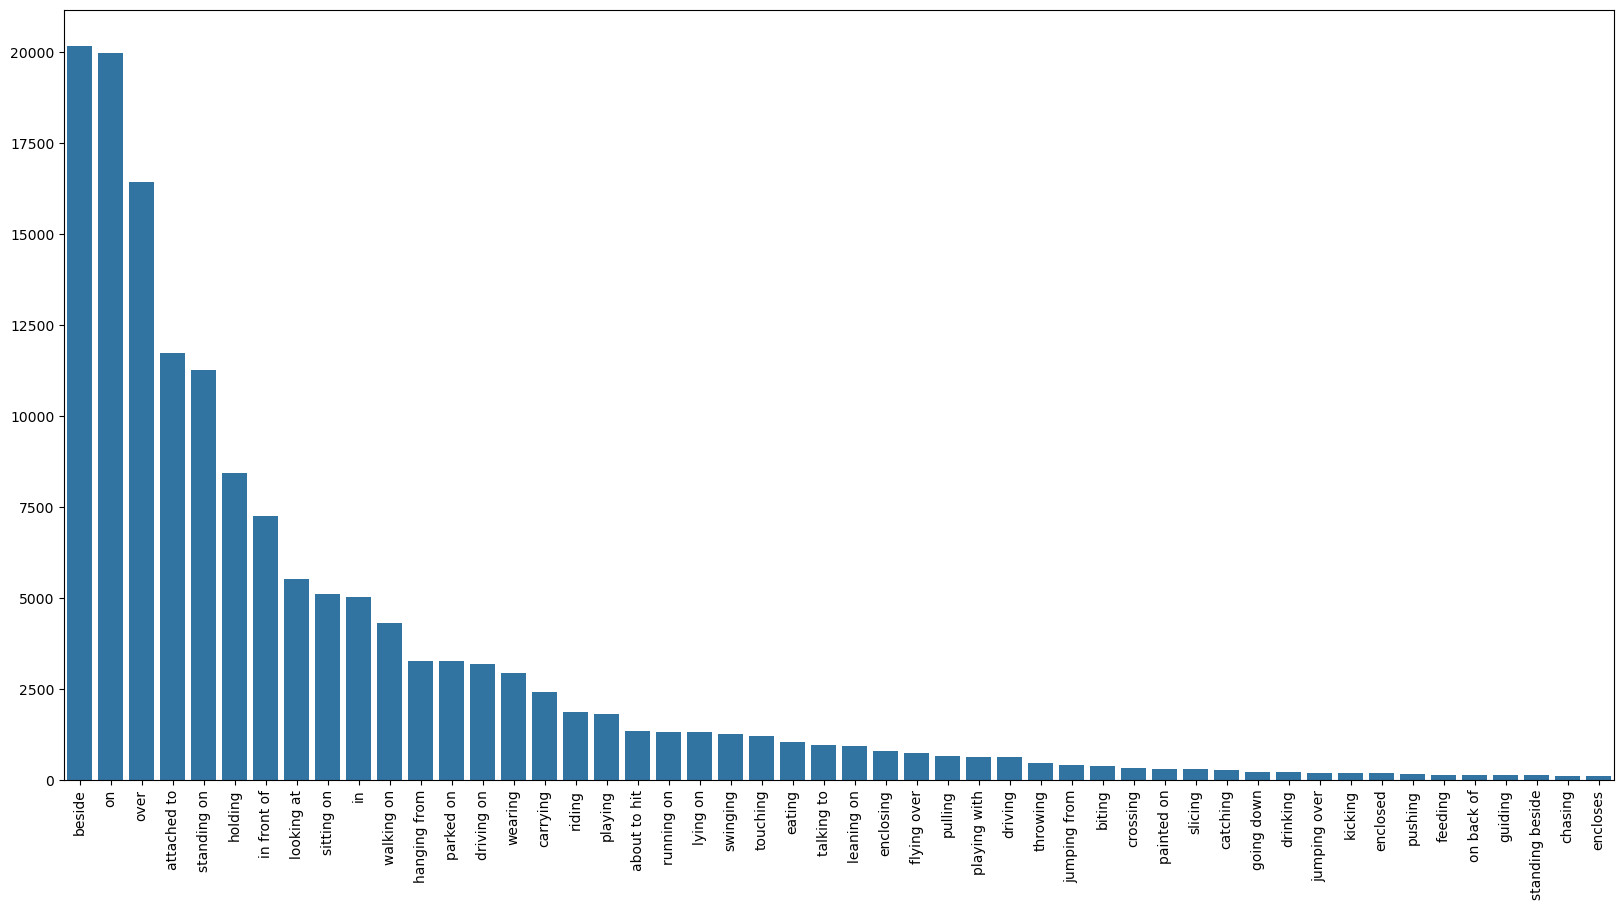

In [20]:
# here we get the predicate distribution
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

rel_count = Counter()
obj_count = 0

img_no_rel = 0

for img in tqdm(anno):
    img_path = coco_path + img['image']
    # load image
    image = Image.open(img_path)
    objects, relations, bbox2category = extract_objects(img['conversations'][1]['value'].replace('<image>', '').replace('</s>', ''))

    rel_count.update(relations.keys())
    obj_count += len(objects)

    if len(relations) == 0:
        img_no_rel += 1

    # scene_graph = parse_caption_and_update_image(image, img['conversations'][1]['value'])
    # objects = img['objects']
    # for rel in scene_graph:
    #     subject, subject_bbox, obj, obj_bbox, rel = rel

    #     if len (subject) == 0 or len(obj) == 0:
    #         continue
    #     subject = subject[0]
    #     obj = obj[0]

    #     rel_count[rel] += 1
    #     obj_count[subject] += 1
    #     obj_count[obj] += 1

# plot predicate distribution
rel_count = dict(rel_count)
rel_count = {k: v for k, v in sorted(rel_count.items(), key=lambda item: item[1], reverse=True)}

print(len(rel_count))
print(obj_count)
# object per image average
print(obj_count / len(anno))

# rel per image average
print(sum(rel_count.values()) / len(anno))
print(rel_count)

# number of images with no relations
print(img_no_rel)

# take only top 50
rel_visu = dict(list(rel_count.items())[:50])

plt.figure(figsize=(20, 10))
sns.barplot(x=list(rel_visu.keys()), y=list(rel_visu.values()))
plt.xticks(rotation=90)
plt.show()

In [ ]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd

rel_count = Counter()
obj_count = 0

img_no_rel = 0

rel_array = []

for img in tqdm(anno):
    img_path = coco_path + img['image']
    # load image
    image = Image.open(img_path)

    scene_graph = parse_caption_and_update_image(image, img['conversations'][1]['value'])
    for rel in scene_graph:
        subject, subject_bbox, obj, obj_bbox, rel = rel

        if len (subject) == 0 or len(obj) == 0:
            continue
        subject = subject[0]
        obj = obj[0]

        rel_array.append([subject, rel, obj])

Number of unique relationships: 37356
         node1          node2  nunique_relations
13708  persons           dirt                  1
13718  persons  motorcyclists                  1
13717  persons    motorcycles                  1
13716  persons     motorcycle                  1
13715  persons           kite                  1
(22002, 3)
1.6168984637760204


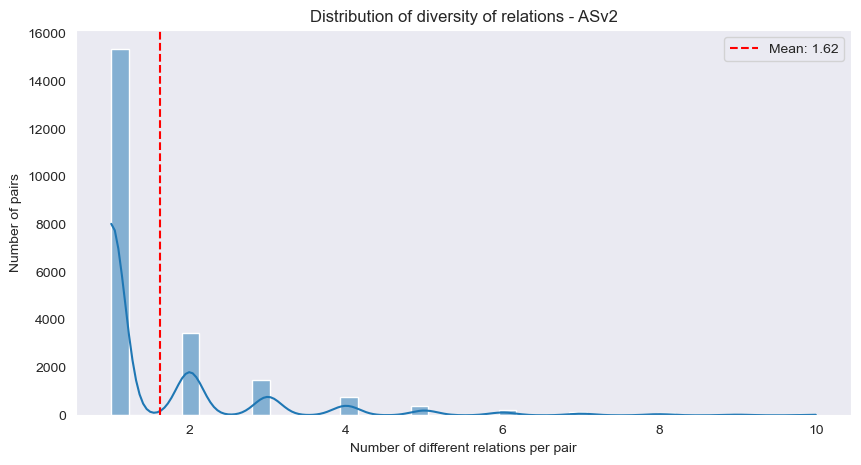

15372
0.6986637578401963
Percentage of pairs with only one relation: 69.87%


In [ ]:
df = pd.DataFrame(rel_array, columns=['node1', 'relation', 'node2'])
relations=df.value_counts()
r=[]
relations=relations.to_dict()

for k,v in relations.items():
    if int(v)>100:
        r.append(k)

value_counts = df.value_counts()

df_val_counts = pd.DataFrame(value_counts)
df_value_counts_reset = df_val_counts.reset_index()
df["full_rel"] = df['node1'].astype(str) +"-"+ df["relation"].astype(str) +"-"+ df["node2"].astype(str)
df_val_counts = df["full_rel"].value_counts()
df_value_counts_reset = df_val_counts.reset_index()
df_value_counts_reset.columns = ['unique_values', 'counts']
print("Number of unique relationships:", len(df_value_counts_reset)) 


# compute the diversity of the relations, i.e. the number of different predicates per subject/object pair
diversity = df.groupby(['node1', 'node2']).agg({'relation': 'nunique'}).reset_index()
diversity = diversity.sort_values('relation', ascending=True)
diversity = diversity.rename(columns={'relation': 'nunique_relations'})

# remove values nunique_relations > 10 for visualization
diversity = diversity[diversity['nunique_relations'] <= 10]
# only top 10
print(diversity.head())
print(diversity.shape)

# average number of relations per pair
avg_relations = diversity['nunique_relations'].mean()
print(avg_relations)

# draw distribution of diversity as a bar chart using seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("dark")

plt.figure(figsize=(10, 5))
sns.histplot(diversity['nunique_relations'], bins=40, kde=True)
# display the mean on the graph with its ber in .2f
plt.axvline(avg_relations, color='r', linestyle='--', label='Mean: {:.2f}'.format(avg_relations))
plt.legend()
plt.title('Distribution of diversity of relations - ASv2')
plt.xlabel('Number of different relations per pair')
plt.ylabel('Number of pairs')
plt.show()
one_rel = diversity[diversity['nunique_relations'] == 1].shape[0]
print(one_rel)
print(one_rel/diversity.shape[0])

# print the % of pairs with only one relation
print("Percentage of pairs with only one relation: {:.2f}%".format(one_rel/diversity.shape[0]*100))

In [ ]:
# get the TSNE of the relations as text embeddings from BERT
from sentence_transformers import SentenceTransformer
import numpy

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

rels = list(rel_count.keys())
import torch

model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# Encode the sentences
embeddings = model.encode(rels, convert_to_tensor=True)
embeddings = embeddings.cpu().numpy()
embeddings = StandardScaler().fit_transform(embeddings)
embeddings = PCA(n_components=50).fit_transform(embeddings)
embeddings = TSNE(n_components=2, perplexity=30, n_iter=300).fit_transform(embeddings)

# display TSNE without labels
plt.figure(figsize=(20, 10))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=10)
plt.title('TSNE of relations')
plt.show()

In [ ]:
# show only top 50
plt.figure(figsize=(20, 10))
sns.barplot(x=list(rel_count.keys())[:50], y=list(rel_count.values())[:50], palette="viridis")
plt.xticks(rotation=75)
plt.title('Top 50 Relative Counts')
plt.xlabel('Predicate', fontsize=12)
plt.ylabel('Count', fontsize=12)
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# compute mean and median of relation per image
rel_sum = sum(rel_count.values())
rel_mean = rel_sum / len(anno)

print(f'Mean relation per image: {rel_mean}')

print(len(rel_count))

In [ ]:
space_sgg_path  = "datasets/space_sgg/gpt4o-space-sgg-desc-10k.json"

with open(space_sgg_path, 'r') as f:
    space_sgg_anno = json.load(f)

print(len(space_sgg_anno))
print(space_sgg_anno[0].keys())


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
coco_path = "datasets/coco/"
import random
random.shuffle(space_sgg_anno)
img_path = coco_path + space_sgg_anno[0]['image']
# load image
image = Image.open(img_path)
scene_graph = parse_caption_and_update_image(image, space_sgg_anno[0]['conversations'][1]['value'])
print(space_sgg_anno[0]['conversations'][1]['value'])

fig, ax = plt.subplots()
ax.imshow(image)

for rel in scene_graph:
    subject, subject_bbox, obj, obj_bbox, rel = rel
    print(subject, subject_bbox, obj, obj_bbox, rel)
    subject = subject[0]
    obj = obj[0]

    # draw bbox

    ax.add_patch(patches.Rectangle((subject_bbox[0], subject_bbox[1]), subject_bbox[2]-subject_bbox[0], subject_bbox[3]-subject_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))
    ax.add_patch(patches.Rectangle((obj_bbox[0], obj_bbox[1]), obj_bbox[2]-obj_bbox[0], obj_bbox[3]-obj_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))

    # get center of bbox
    subject_center = ((subject_bbox[0] + subject_bbox[2]) / 2, (subject_bbox[1] + subject_bbox[3]) / 2)
    obj_center = ((obj_bbox[0] + obj_bbox[2]) / 2, (obj_bbox[1] + obj_bbox[3]) / 2)

    # draw line
    ax.plot([subject_center[0], obj_center[0]], [subject_center[1], obj_center[1]], 'blue')

    # draw bboxes labels on top left with background rectangle
    ax.text(subject_bbox[0], subject_bbox[1], subject, fontsize=10, color='white', backgroundcolor='red')
    ax.text(obj_bbox[0], obj_bbox[1], obj, fontsize=10, color='white', backgroundcolor='red')

    # draw relation label on center of line
    ax.text((subject_center[0] + obj_center[0]) / 2, (subject_center[1] + obj_center[1]) / 2, rel, fontsize=12, color='blue')

# remove ticks
ax.set_xticks([])
ax.set_yticks([])
plt.show()

100%|██████████| 10104/10104 [01:28<00:00, 113.98it/s]
/tmp/ipykernel_1772716/834713699.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(rel_count.keys())[:50], y=list(rel_count.values())[:50], palette="viridis")


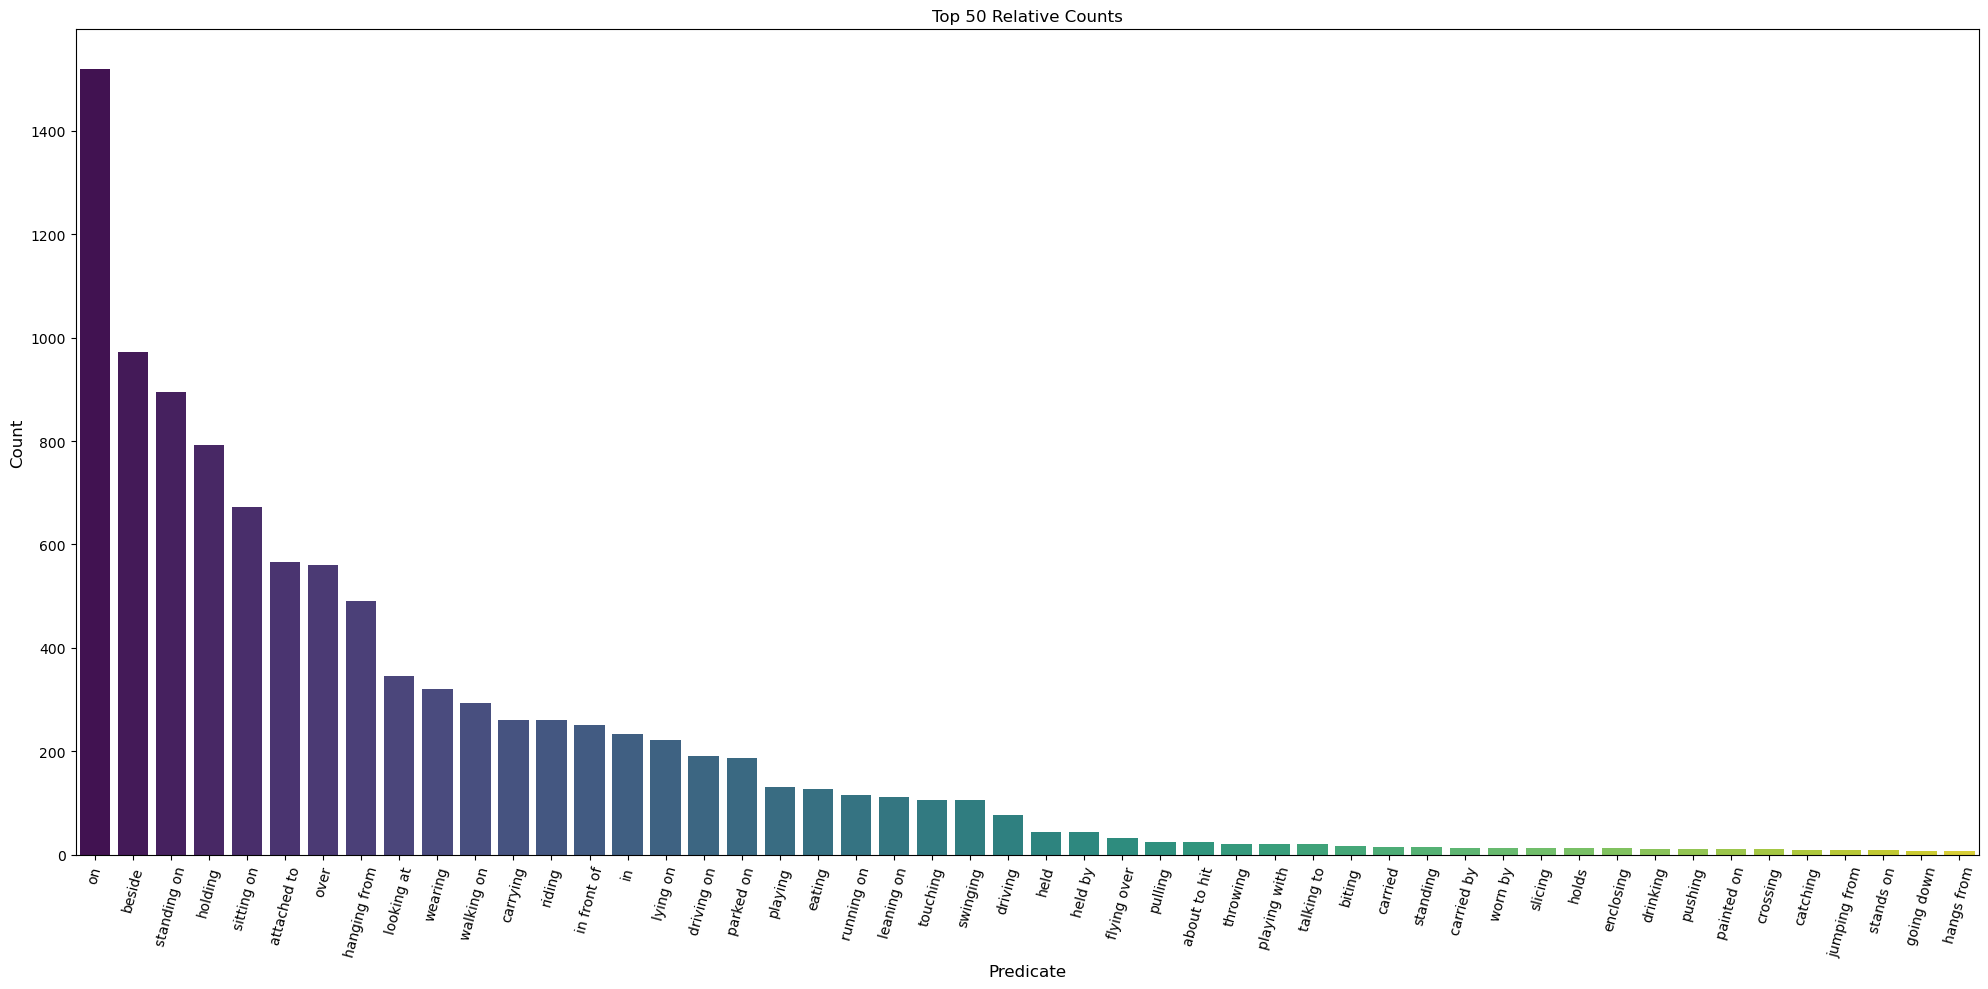

In [ ]:
# here we get the predicate distribution
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

rel_count = Counter()
obj_count = Counter()

for img in tqdm(space_sgg_anno):
    img_path = coco_path + img['image']
    # load image
    image = Image.open(img_path)
    scene_graph = parse_caption_and_update_image(image, img['conversations'][1]['value'])
    for rel in scene_graph:
        subject, subject_bbox, obj, obj_bbox, rel = rel

        if len (subject) == 0 or len(obj) == 0:
            continue
        subject = subject[0]
        obj = obj[0]

        rel_count[rel] += 1
        obj_count[subject] += 1
        obj_count[obj] += 1

# plot predicate distribution
rel_count = dict(rel_count)
rel_count = {k: v for k, v in sorted(rel_count.items(), key=lambda item: item[1], reverse=True)}

# show only top 50
plt.figure(figsize=(20, 10))
sns.barplot(x=list(rel_count.keys())[:50], y=list(rel_count.values())[:50], palette="viridis")
plt.xticks(rotation=75)
plt.title('Top 50 Relative Counts')
plt.xlabel('Predicate', fontsize=12)
plt.ylabel('Count', fontsize=12)
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()